# 04 — Model Evaluation

## Smart India Real Estate Analytics

### Objective
Evaluate the trained XGBoost regression model on the unseen test dataset.

### Evaluation Metrics
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

### Important
The test dataset was not used during model training.

In [3]:

import pandas as pd
import joblib
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [4]:
MODEL_DIR = Path("../models")

model = joblib.load(
    MODEL_DIR / "xgboost_model.joblib"
)

X_test_processed = joblib.load(
    MODEL_DIR / "X_test_processed.joblib"
)

y_test = joblib.load(
    MODEL_DIR / "y_test.joblib"
)

print("Model and test data loaded successfully.")
print("Test features:", X_test_processed.shape)
print("Test target:", y_test.shape)

Model and test data loaded successfully.
Test features: (2904, 6026)
Test target: (2904,)


In [4]:
y_pred = model.predict(X_test_processed)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))
print("\nFirst 10 predictions:")
print(y_pred[:10])

Predictions generated successfully.
Number of predictions: 2904

First 10 predictions:
[1.9046990e+07 4.4020210e+06 4.1800132e+07 4.2262525e+06 6.4681145e+06
 1.2052871e+07 7.8161490e+06 4.4020210e+06 1.2914327e+07 1.6807086e+07]


In [5]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=" * 45)
print("XGBoost Test Set Evaluation")
print("=" * 45)

print(f"MAE :  ₹{mae:,.2f}")
print(f"RMSE:  ₹{rmse:,.2f}")
print(f"R²  :  {r2:.4f}")

XGBoost Test Set Evaluation
MAE :  ₹5,695,869.39
RMSE:  ₹17,352,118.59
R²  :  -0.0659


In [6]:
print("Actual price statistics:")
print(y_test.describe())

print("\nPredicted price statistics:")
print(pd.Series(y_pred).describe())

Actual price statistics:
count    2.904000e+03
mean     1.064120e+07
std      1.680975e+07
min      1.000000e+05
25%      3.800000e+06
50%      6.500000e+06
75%      1.142500e+07
max      3.000000e+08
Name: Price_numeric, dtype: float64

Predicted price statistics:
count    2.904000e+03
mean     1.036552e+07
std      1.360297e+07
min      3.594830e+06
25%      4.904046e+06
50%      6.468114e+06
75%      1.152549e+07
max      5.525923e+08
dtype: float64


In [7]:
y_train = joblib.load(
    MODEL_DIR / "y_train.joblib"
)

print("Training target loaded.")
print("Training target shape:", y_train.shape)

Training target loaded.
Training target shape: (11613,)


In [8]:
baseline_prediction = y_train.mean()

baseline_mae = mean_absolute_error(
    y_test,
    [baseline_prediction] * len(y_test)
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        [baseline_prediction] * len(y_test)
    )
)

baseline_r2 = r2_score(
    y_test,
    [baseline_prediction] * len(y_test)
)

print("Mean Price Baseline")
print("=" * 40)
print(f"MAE :  ₹{baseline_mae:,.2f}")
print(f"RMSE:  ₹{baseline_rmse:,.2f}")
print(f"R²  :  {baseline_r2:.4f}")

Mean Price Baseline
MAE :  ₹8,041,225.23
RMSE:  ₹16,806,917.49
R²  :  -0.0000


## Experiment 2 — Log-Target XGBoost Evaluation

The model was trained using a log-transformed target:

`log1p(Price)`

Predictions are converted back to the original price scale using:

`expm1()`

The resulting predictions are evaluated against the original test prices using MAE, RMSE, and R².

In [9]:
# Load Experiment 2 model

model_log = joblib.load(
    MODEL_DIR / "xgboost_log_target_model.joblib"
)

print("Log-target XGBoost model loaded successfully.")

Log-target XGBoost model loaded successfully.


In [10]:
# Generate predictions in log scale
y_pred_log = model_log.predict(X_test_processed)

# Convert predictions back to original price scale
y_pred_log_original = np.expm1(y_pred_log)

print("Log-target predictions generated successfully.")
print("Number of predictions:", len(y_pred_log_original))

Log-target predictions generated successfully.
Number of predictions: 2904


In [11]:
mae_log = mean_absolute_error(
    y_test,
    y_pred_log_original
)

rmse_log = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_log_original
    )
)

r2_log = r2_score(
    y_test,
    y_pred_log_original
)

print("=" * 45)
print("Log-Target XGBoost Evaluation")
print("=" * 45)

print(f"MAE :  ₹{mae_log:,.2f}")
print(f"RMSE:  ₹{rmse_log:,.2f}")
print(f"R²  :  {r2_log:.4f}")

Log-Target XGBoost Evaluation
MAE :  ₹4,897,341.79
RMSE:  ₹13,856,375.40
R²  :  0.3203


## Experiment 2 — Conclusion

The log-target XGBoost model significantly outperformed the original-target XGBoost model.

By applying `log1p()` to the highly right-skewed `Price_numeric` target, the model achieved:

- MAE: ₹48.97 lakh
- RMSE: ₹1.386 crore
- R²: 0.3203

Compared with the baseline XGBoost model, both MAE and RMSE decreased, while R² improved substantially from -0.0659 to 0.3203.

The log-target XGBoost model is therefore selected as the current best model.

## Experiment 3 — Error Analysis

The selected log-target XGBoost model is further analyzed using actual versus predicted prices.

This analysis helps identify whether the model systematically overestimates or underestimates property prices and whether prediction errors increase for expensive properties.

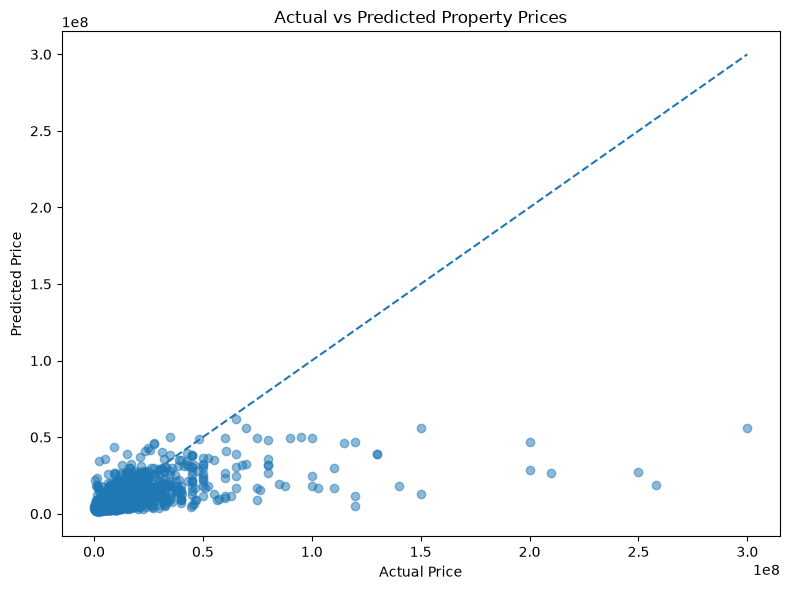

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_log_original, alpha=0.5)

# Perfect prediction line
min_price = min(y_test.min(), y_pred_log_original.min())
max_price = max(y_test.max(), y_pred_log_original.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Property Prices")

plt.tight_layout()
plt.show()

In [13]:
residuals = y_test - y_pred_log_original

print("Mean Residual:", residuals.mean())
print("Median Residual:", residuals.median())
print("Minimum Residual:", residuals.min())
print("Maximum Residual:", residuals.max())

Mean Residual: 2211054.550878099
Median Residual: -332005.375
Minimum Residual: -34338372.0
Maximum Residual: 244252572.0


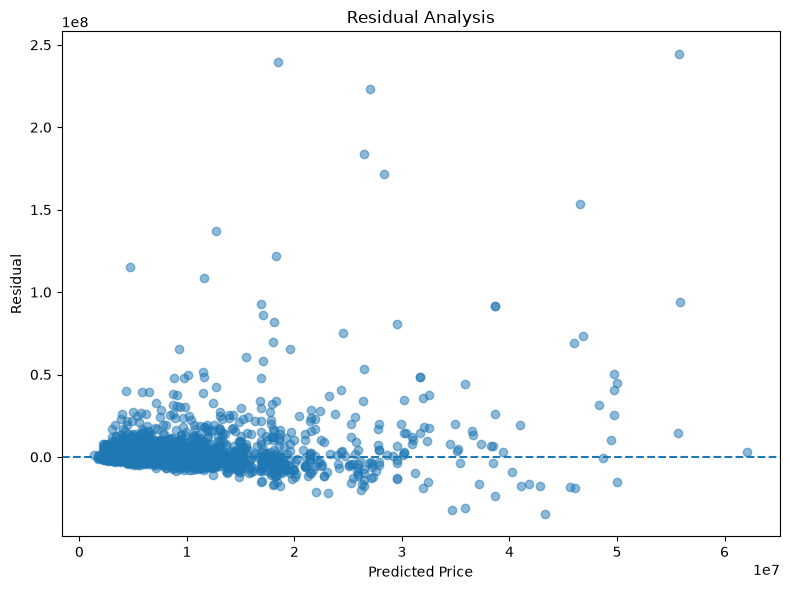

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(y_pred_log_original, residuals, alpha=0.5)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Analysis")

plt.tight_layout()
plt.show()

## Experiment 4 — Error Analysis by Price Range

The prediction error is analyzed across different actual property-price ranges.

This helps determine whether model performance changes significantly for lower-priced, mid-range, and high-priced properties.

In [15]:
import pandas as pd
import numpy as np

error_analysis = pd.DataFrame({
    "Actual_Price": y_test.values,
    "Predicted_Price": y_pred_log_original
})

error_analysis["Absolute_Error"] = (
    error_analysis["Actual_Price"] -
    error_analysis["Predicted_Price"]
).abs()

error_analysis["Price_Range"] = pd.cut(
    error_analysis["Actual_Price"],
    bins=[0, 50_00_000, 1_00_00_000, 2_00_00_000, np.inf],
    labels=[
        "Below ₹50L",
        "₹50L–₹1Cr",
        "₹1Cr–₹2Cr",
        "Above ₹2Cr"
    ]
)

range_summary = error_analysis.groupby(
    "Price_Range",
    observed=True
)["Absolute_Error"].agg(
    Count="count",
    MAE="mean"
)

range_summary

,Count,MAE
Price_Range,,
Below ₹50L,1106,1.755095e+06
₹50L–₹1Cr,992,2.256185e+06
₹1Cr–₹2Cr,525,5.282688e+06
Above ₹2Cr,281,2.586903e+07


In [16]:
range_summary["MAE_Lakh"] = range_summary["MAE"] / 1_00_000

range_summary

,Count,MAE,MAE_Lakh
Price_Range,,,
Below ₹50L,1106,1.755095e+06,17.550953
₹50L–₹1Cr,992,2.256185e+06,22.561854
₹1Cr–₹2Cr,525,5.282688e+06,52.826885
Above ₹2Cr,281,2.586903e+07,258.690314


## Final Model Evaluation

The selected XGBoost model is retrained using the complete training dataset after model selection based on the validation set.

The final model is evaluated on the previously untouched test dataset using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score.

The predictions are converted back from the logarithmic scale to the original price scale using `expm1()` before calculating the evaluation metrics.

In [5]:
import joblib
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

final_model = joblib.load(
    "../models/xgboost_final_model.joblib"
)

y_pred_final_log = final_model.predict(X_test_processed)

# Convert predictions back to original price scale
y_pred_final = np.expm1(y_pred_final_log)

mae_final = mean_absolute_error(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_final = r2_score(y_test, y_pred_final)

print("Final Model Performance")
print("-----------------------")
print(f"MAE  : ₹{mae_final:,.2f}")
print(f"RMSE : ₹{rmse_final:,.2f}")
print(f"R²   : {r2_final:.4f}")

Final Model Performance
-----------------------
MAE  : ₹4,847,093.25
RMSE : ₹13,629,108.32
R²   : 0.3424


## Final Evaluation — Conclusion

The final log-target XGBoost model with `max_depth=8` was evaluated on the previously untouched test dataset.

The model achieved:

- MAE: ₹48.47 lakh
- RMSE: ₹1.363 crore
- R²: 0.3424

Compared with the previous log-target XGBoost model with `max_depth=6`, the final model achieved lower MAE and RMSE and a higher R² score.

The final model is therefore selected as the current best-performing model for the Smart India Real Estate Analytics project.